In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from google.colab import files
#uploaded_file = files.upload()
#run above statment only once and then comment to avoid uploading file every time the cell in run

In [58]:
#q1 supervised learning task1
df = pd.read_csv("q1_heart_disease.csv")
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum()) #total null values for each column
print("\nFirst 5 rows:\n", df.head(5))

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:
    age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       114.0    

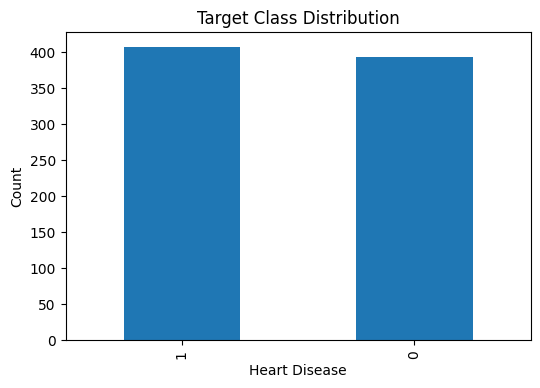

In [59]:
#q1 supervised learning task2
# Target Class Distribution
df.columns
plt.figure(figsize=(6, 4))
df['heart_disease'].value_counts().plot(kind='bar')
plt.title("Target Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

In [60]:
# The target variable (heart_disease) is relatively balanced between classes 0 and 1,
# with a slight majority of patients having heart disease (class = 1). This is beneficial for
# modeling, as balanced datasets reduce bias and improve model performance.

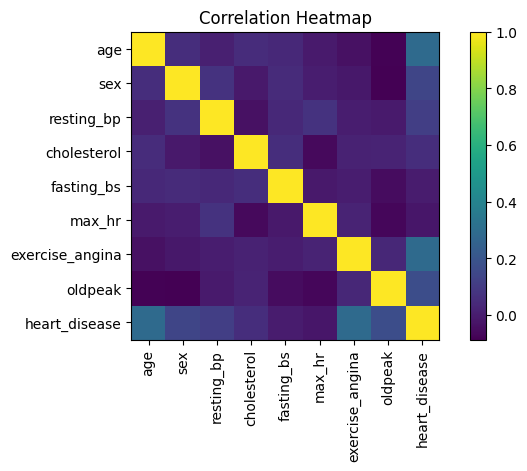

In [61]:
# Correlation Heatmap
plt.figure(figsize=(8, 4))
corr = df.select_dtypes(include='number').corr()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

In [62]:
#The heatmap shows that features like exercise_angina, age and oldpeak have a noticeable positive correlation with heart_disease, indicating they are
#important predictors. Most other features have weak correlations, suggesting that heart disease depends on multiple combined factors rather than a
#single variable.

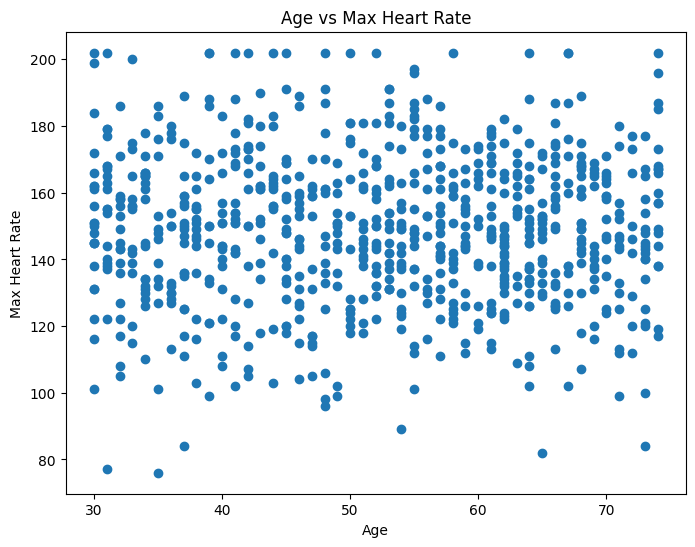

In [63]:
# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df['age'], df['max_hr'])
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.title("Age vs Max Heart Rate")
plt.show()

In [64]:
# There is a slight negative relationship between age and maximum heart rate, meaning older individuals tend to have lower maximum heart rates.
# However, the data points are widely spread meaning that age alone is not a strong predictor.

In [65]:
#task 3 - data preprocessing
# Separate column types and fill missing values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns #numerical columns
cat_cols = df.select_dtypes(include=['object']).columns           #categorical columns


df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [66]:
#Numerical columns → filled using median imputation. Reason: Median is robust to outliers and suitable for medical data.
#Categorical columns → filled using mode. Reason: Mode represents the most frequent category.
#Ensures minimal data loss while maintaining distribution.

In [67]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded_data = encoder.fit_transform(df[cat_cols])         #applied one hot encoder
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(cat_cols)
)                                                          #converted encoded data into dataframe
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(cat_cols)
)

df = df.drop(columns=cat_cols)
df = pd.concat([df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)  #replace original categorical columns with new encoded columns

In [68]:
scaler = StandardScaler()
X = df.drop('heart_disease', axis=1) #exclude target variable from X and include in Y
y = df['heart_disease']

X_scaled = scaler.fit_transform(X)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)

In [70]:
#task 4 model training
#Decesion tree
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)
dtc_preds = dtc_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dtc_preds))

#Random forest
rfc_model = RandomForestClassifier(random_state=42)
rfc_model.fit(X_train, y_train)
rfc_preds = rfc_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rfc_preds))

#gradient boosting
gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train, y_train)
gbc_preds = gbc_model.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gbc_preds))

Decision Tree Accuracy: 0.7291666666666666
Random Forest Accuracy: 0.7958333333333333
Gradient Boosting Accuracy: 0.8041666666666667


Decision Tree Confusion Matrix:


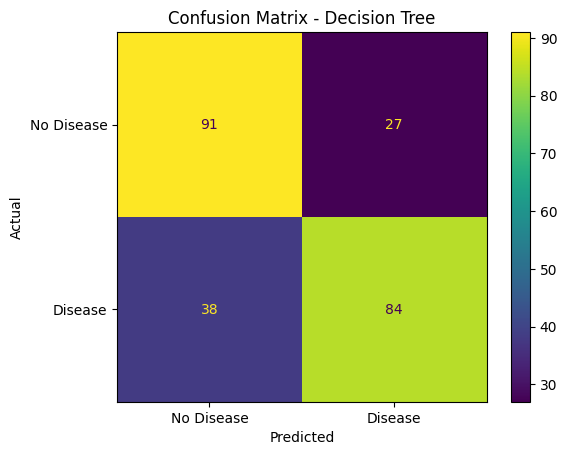

Decision Tree Test Recall: 0.6885245901639344
Decision Tree Test Precision: 0.7567567567567568
Decision Tree Test F1 Score: 0.721030042918455
Random Forest Confusion Matrix:


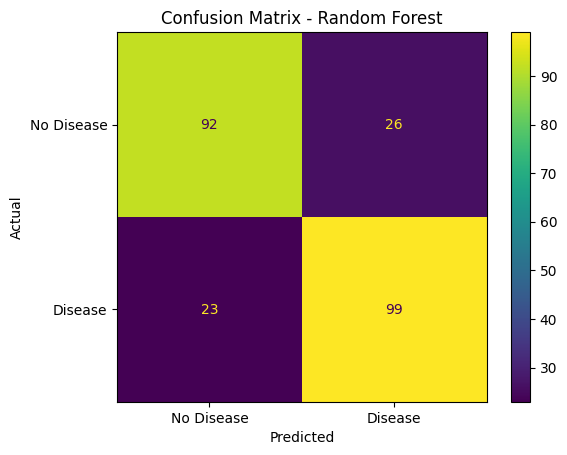

Random forest Test Recall: 0.8114754098360656
Random forest Test Precision: 0.792
Random forest Test F1 Score: 0.8016194331983806
Gradient Boosting Confusion Matrix:


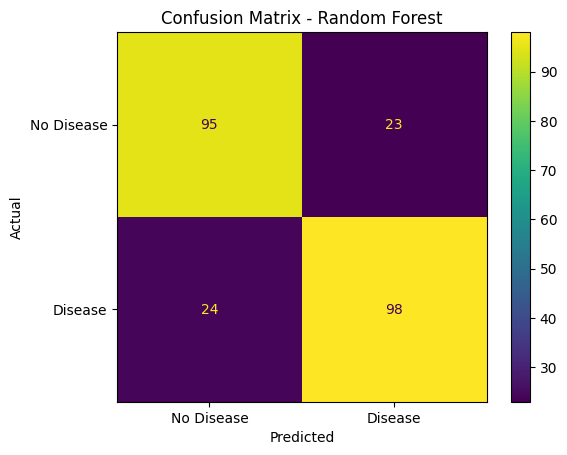

Gradient boosting Test Recall: 0.8032786885245902
Gradient boosting Test Precision: 0.8099173553719008
Gradient boosting Test F1 Score: 0.8065843621399177


In [71]:
#task5 model evaluation
#Decision tree evaluation
print("Decision Tree Confusion Matrix:")
dtc_cmd = ConfusionMatrixDisplay.from_predictions(
    y_test,
    dtc_preds,
    labels=[0, 1],
    display_labels=["No Disease", "Disease"]
)
dtc_cmd.ax_.set_xlabel("Predicted")
dtc_cmd.ax_.set_ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

dtc_recall = recall_score(y_test, dtc_preds)
dtc_precision = precision_score(y_test, dtc_preds)
dtc_f1 = f1_score(y_test, dtc_preds)
print("Decision Tree Test Recall:", dtc_recall)
print("Decision Tree Test Precision:", dtc_precision)
print("Decision Tree Test F1 Score:", dtc_f1)


#Random forest evaluation
print("Random Forest Confusion Matrix:")
rfc_cmd = ConfusionMatrixDisplay.from_predictions(
    y_test,
    rfc_preds,
    labels=[0, 1],
    display_labels=["No Disease", "Disease"]
)

rfc_cmd.ax_.set_xlabel("Predicted")
rfc_cmd.ax_.set_ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()
rfc_recall = recall_score(y_test, rfc_preds)
rfc_precision = precision_score(y_test, rfc_preds)
rfc_f1 = f1_score(y_test, rfc_preds)
print("Random forest Test Recall:", rfc_recall)
print("Random forest Test Precision:", rfc_precision)
print("Random forest Test F1 Score:", rfc_f1)

#Gradient boosting evaluation
print("Gradient Boosting Confusion Matrix:")
gbc_cmd = ConfusionMatrixDisplay.from_predictions(
    y_test,
    gbc_preds,
    labels=[0, 1],
    display_labels=["No Disease", "Disease"]
)

gbc_cmd.ax_.set_xlabel("Predicted")
gbc_cmd.ax_.set_ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()
gbc_recall = recall_score(y_test, gbc_preds)
gbc_precision = precision_score(y_test, gbc_preds)
gbc_f1 = f1_score(y_test, gbc_preds)
print("Gradient boosting Test Recall:", gbc_recall)
print("Gradient boosting Test Precision:", gbc_precision)
print("Gradient boosting Test F1 Score:", gbc_f1)

In [72]:
#Out of all 3 models, Decision tree has low accuracy, recall, precision, F1 score compared to all so that's the worst performing model.
#For the patients data, missing patients (false nagative) matters hence recall matters but false alarm also matters hence precision is also
#important. Even though recall is slightly higher for Random forest classifier, in both precision and F1 score Gradient boosting classifier
#is better hence Gradient Boosting Calssifier is the best performing model by slight margin.

In [73]:
#task 6 hyperparameter tuning (n_estimators, learning_rate and max_depth)
params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

tuned_model = grid.best_estimator_

y_pred_tuned = tuned_model.predict(X_test)

print("\nTuned Model Performance:\n")
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned )
tuned_precision = precision_score(y_test, y_pred_tuned )
tuned_f1 = f1_score(y_test, y_pred_tuned )
print("Tuned Accuracy:", tuned_accuracy)
print("Tuned Test Recall:", tuned_recall)
print("Tuned Test Precision:", tuned_precision)
print("Tuned Test F1 Score:", tuned_f1)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Tuned Model Performance:

Tuned Accuracy: 0.8041666666666667
Tuned Test Recall: 0.8032786885245902
Tuned Test Precision: 0.8099173553719008
Tuned Test F1 Score: 0.8065843621399177


In [74]:
#After tuning the model with 3 parameters, it is found that the model performed very similar to the baseline model that was already trained
#This shows that the oeiginal model was already well optimized and similar performance even after tuning proved the stability of model